In [1]:
import os

**Dataset Link**
https://www.kaggle.com/competitions/playground-series-s5e4/data

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Data Manipulation and Numerical Operations
import numpy as np
import pandas as pd

# Preview the train dataset
train_df = pd.read_csv("/kaggle/input/playground-series-s5e4/train.csv")
train_df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [7]:
# Preview the test dataset
test_df = pd.read_csv("/kaggle/input/playground-series-s5e4/test.csv")
test_df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral


In [8]:
# Check the shape of the train and test datasets
print(train_df.shape)
print(test_df.shape)

(750000, 12)
(250000, 11)


In [9]:
# Check the datatypes of the train and test datasets
print(train_df.dtypes)

id                               int64
Podcast_Name                    object
Episode_Title                   object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                 object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment               object
Listening_Time_minutes         float64
dtype: object


In [10]:
# Check the null values in train and test datasets
print("Null values in Train Dataset : ", train_df.isnull().sum())
print("\nNull values in Test Dataset : ", test_df.isnull().sum())

Null values in Train Dataset :  id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

Null values in Test Dataset :  id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64


In [11]:
# Fill the missing values in the train and test datasets
missing_feature_list = ['Episode_Length_minutes', 'Guest_Popularity_percentage', 'Number_of_Ads']
for col in missing_feature_list:
    train_df[col].fillna(train_df[col].mean(), inplace=True)
    test_df[col].fillna(test_df[col].mean(), inplace=True)

In [12]:
# After filling the missing values check if null values are present or not
print(train_df.isnull().sum())
print(test_df.isnull().sum())

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64
id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
dtype: int64


In [13]:
# Remove unwanted features
train_df.drop(columns=['id', 'Podcast_Name', 'Episode_Title'], inplace=True)

In [14]:
from sklearn.preprocessing import LabelEncoder
import pickle

# Encoding the categorical data
encoders  = {} # Store the encoders in adictionery format for further use
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        encoder = LabelEncoder()
        train_df[col] = encoder.fit_transform(train_df[col])
        encoders[col] = encoder

# Save the path of the encoders
with open("xgboost_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("XGBoost encoders dumped successfully!")

XGBoost encoders dumped successfully!


In [15]:
# After encoding check the datatypes of features
train_df.dtypes

Episode_Length_minutes         float64
Genre                            int64
Host_Popularity_percentage     float64
Publication_Day                  int64
Publication_Time                 int64
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment                int64
Listening_Time_minutes         float64
dtype: object

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


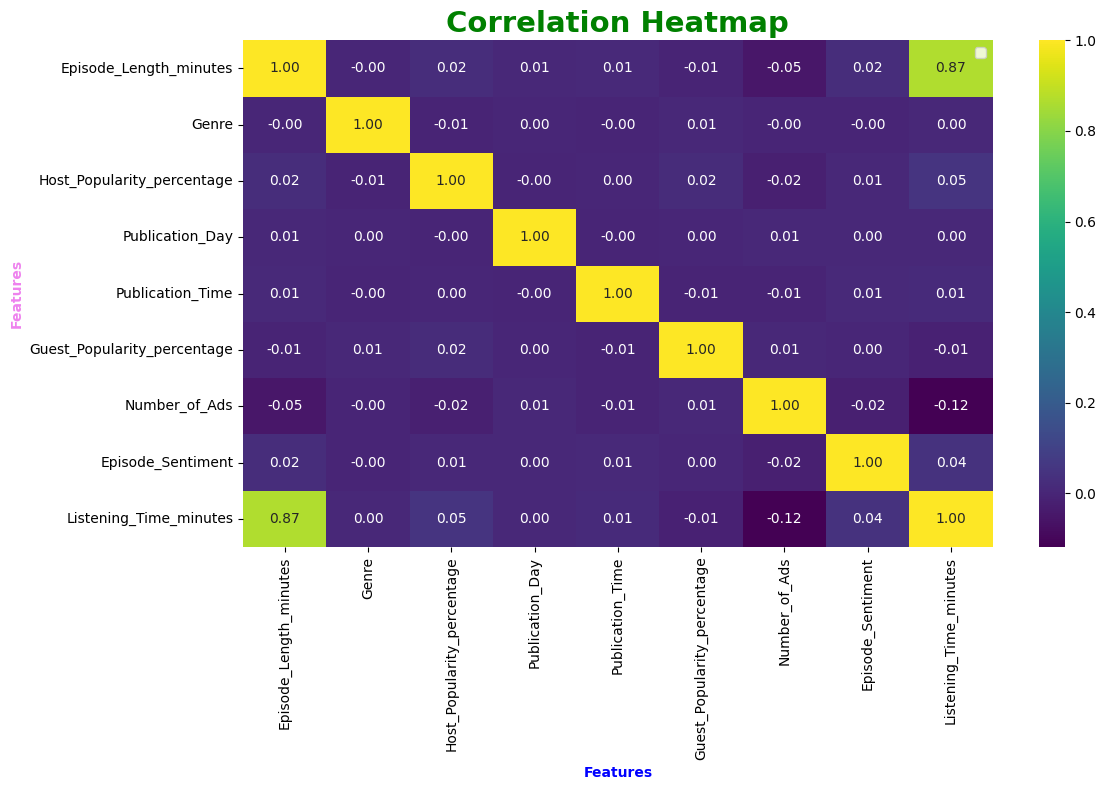

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


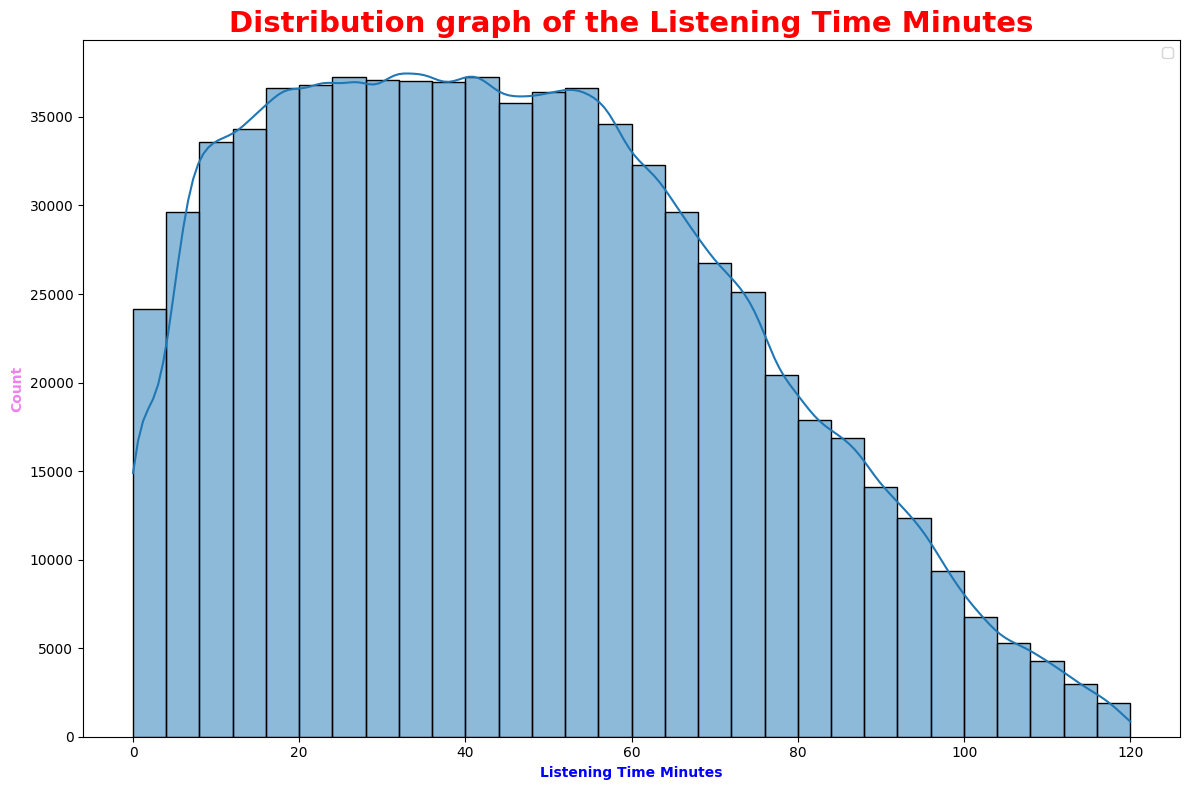

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


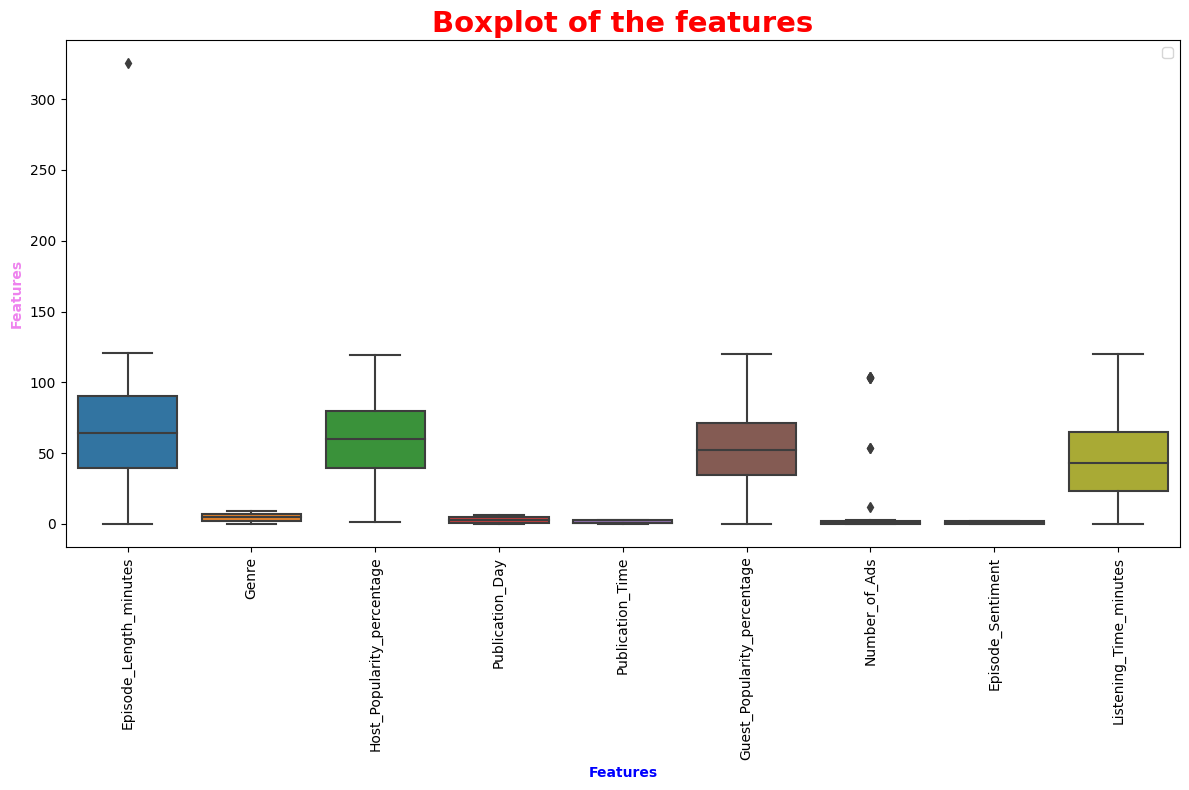

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap to check how a feature is correlated to each other
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap", color='green', fontsize=21, fontweight='bold')
plt.xlabel("Features", color='blue', fontweight='bold')
plt.ylabel("Features", color='violet', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Distribution of the target variable(Whether is skewed, left skewed, right skewed)
plt.figure(figsize=(12,8))
sns.histplot(train_df['Listening_Time_minutes'], kde=True, bins=30)
plt.title("Distribution graph of the Listening Time Minutes", color='red', fontsize='21', fontweight='bold')
plt.xlabel("Listening Time Minutes", color='blue', fontweight='bold')
plt.ylabel("Count", color='violet', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot to check the outliers
plt.figure(figsize=(12,8))
sns.boxplot(data=train_df)
plt.title("Boxplot of the features", color='red', fontsize='21', fontweight='bold')
plt.xlabel("Features", color='blue', fontweight='bold')
plt.ylabel("Features", color='violet', fontweight='bold')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
from sklearn.ensemble import IsolationForest
import pandas as pd

# Select the numeric columns only
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
X = train_df[numeric_cols]

# Fit and predict the IsolationForestModel
iso = IsolationForest(
    contamination=0.02,   # roughly 2% of data are expected to be outliers
    random_state=42,
    n_estimators=100,
)
y_pred = iso.fit_predict(X)

# Count of outliers
print("Outlier counts:", (y_pred == -1).sum())

# Remove the outliers
train_df = train_df[y_pred == 1]

print(f"Original dataset shape: {train_df.shape}")
print(f"After removing outliers: {train_df.shape}")

Outlier counts: 15000
Original dataset shape: (735000, 9)
After removing outliers: (735000, 9)


In [18]:
# All shape, dtype and missing value confirmations
print(train_df.shape)
print(train_df.dtypes)
print(train_df.isnull().sum())

(735000, 9)
Episode_Length_minutes         float64
Genre                            int64
Host_Popularity_percentage     float64
Publication_Day                  int64
Publication_Time                 int64
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment                int64
Listening_Time_minutes         float64
dtype: object
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64


In [19]:
from sklearn.model_selection import train_test_split, cross_val_score

# Extract the dependent and independent variables
X = train_df.drop(columns=['Listening_Time_minutes'])
y = train_df['Listening_Time_minutes']

# Train and the test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Scale the dataset
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the path
with open("xgboost_scalers", "wb") as f:
    pickle.dump(scaler, f)

print("XGBOost scalers dumped successfully!")

XGBOost scalers dumped successfully!


In [21]:
# Principla component analysis to decompose or reduce the non varianced features
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
pca.fit_transform(X_train_scaled)

print("Before PCA : ", X_train.shape[1])
print("After PCA : ", X_train.shape[1])

Before PCA :  8
After PCA :  8


In [22]:
# Convert the float64 datatype to float32
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

In [23]:
import xgboost as xgb
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Define Optuna Objective Function
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'gpu_hist',
        'grow_policy': 'lossguide',
        'verbosity': 0,
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
        'eta': trial.suggest_float('eta', 1e-4, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
    }

    if params['booster'] == 'dart':
        params['sample_type'] = trial.suggest_categorical('sample_type', ['uniform', 'weighted'])
        params['normalize_type'] = trial.suggest_categorical('normalize_type', ['tree', 'forest'])
        params['rate_drop'] = trial.suggest_float('rate_drop', 1e-8, 0.5, log=True)

    # Build a model
    model = xgb.XGBRegressor(
        n_estimators=500, 
        random_state=42,
        n_jobs=-1,
        **params
    )

    # Pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Evaluate using 5-fold CV with R² metric
    score = cross_val_score(pipeline, X_train_scaled, y_train, scoring='r2', cv=5, n_jobs=-1)
    return np.mean(score)

In [25]:
# Build a model + GPU + Optuna Optimization + Suggesting Hyperparameters + Pipelining the model + Predicting

import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Optuna Objective Function
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'gpu_hist',     
        'predictor': 'gpu_predictor',  
        'grow_policy': 'lossguide',
        'verbosity': 0,
        'sampling_method': 'gradient_based',
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
        'eta': trial.suggest_float('eta', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    if params['booster'] == 'dart':
        params['sample_type'] = trial.suggest_categorical('sample_type', ['uniform', 'weighted'])
        params['normalize_type'] = trial.suggest_categorical('normalize_type', ['tree', 'forest'])
        params['rate_drop'] = trial.suggest_float('rate_drop', 1e-8, 0.5, log=True)

    # GPU-based model
    model = xgb.XGBRegressor(
        n_estimators=200,       
        random_state=42,
        n_jobs=-1,
        **params
    )

    # Pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # 3-fold CV for speed with large dataset
    score = cross_val_score(pipeline, X_train, y_train, scoring='r2', cv=3, n_jobs=-1)
    return np.mean(score)

# Enable pruning to skip bad trials early
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)

# Create & run Optuna study
study = optuna.create_study(direction="maximize", pruner=pruner)
study.optimize(objective, n_trials=10, show_progress_bar=True)

# Print best parameters
print("Best Hyperparameters:", study.best_trial.params)
print("Best R2 Score:", study.best_trial.value)

# Train Final GPU Model with Best Params
best_params = study.best_trial.params
best_params.update({
    'objective': 'reg:squarederror',
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor',
    'verbosity': 0,
    'random_state': 42,
    'n_jobs': -1
})

xgboost_model = xgb.XGBRegressor(
    n_estimators=10,          
    early_stopping_rounds=30,  
    **best_params
)

# Fit the model and predict
xgboost_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred = xgboost_model.predict(X_test)

[I 2026-01-01 16:45:44,485] A new study created in memory with name: no-name-358ac3fe-8aa3-4821-9b5f-13a5cca2105f


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-01-01 16:45:49,180] Trial 0 finished with value: 0.3601189808618033 and parameters: {'booster': 'gbtree', 'lambda': 0.005812234932942576, 'alpha': 0.0007949960264361218, 'eta': 0.0018934128775298473, 'max_depth': 3, 'min_child_weight': 15, 'subsample': 0.6019076711285508, 'colsample_bytree': 0.9860973209409964}. Best is trial 0 with value: 0.3601189808618033.
[I 2026-01-01 16:46:47,647] Trial 1 finished with value: 0.23299219261223883 and parameters: {'booster': 'dart', 'lambda': 7.404440667665055e-07, 'alpha': 1.3276200111276675e-07, 'eta': 0.0013757095068111132, 'max_depth': 5, 'min_child_weight': 11, 'subsample': 0.8799064316449196, 'colsample_bytree': 0.7327431054074884, 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 6.430473158182203e-07}. Best is trial 0 with value: 0.3601189808618033.
[I 2026-01-01 16:47:41,576] Trial 2 finished with value: 0.7527994771394296 and parameters: {'booster': 'dart', 'lambda': 0.009379685338439112, 'alpha': 0.172235496865403

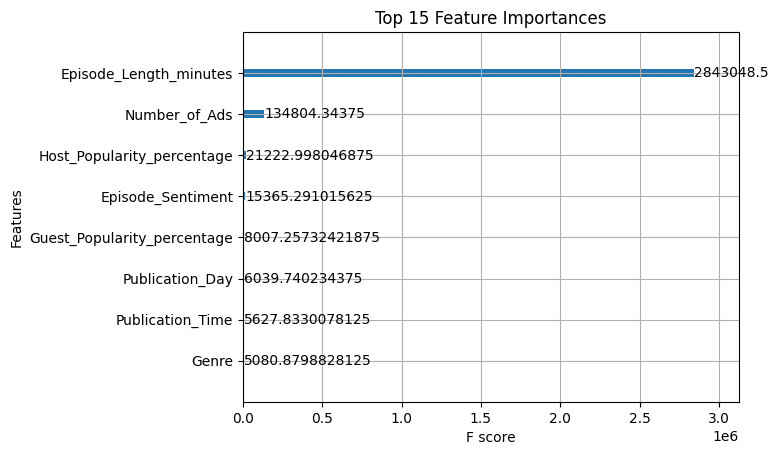

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


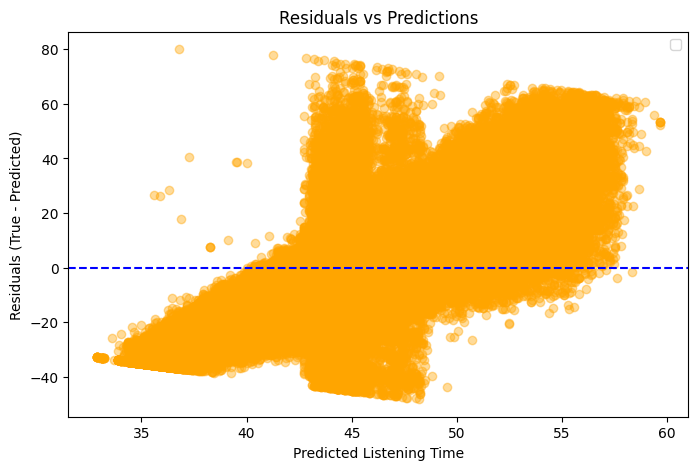

In [26]:
# Visualization: Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns
xgb.plot_importance(xgboost_model, importance_type='gain', max_num_features=15)
plt.title("Top 15 Feature Importances")
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4, color='orange')
plt.axhline(0, color='blue', linestyle='--')
plt.xlabel("Predicted Listening Time")
plt.ylabel("Residuals (True - Predicted)")
plt.title("Residuals vs Predictions")
plt.legend()
plt.show()

In [27]:
train_df.head()

,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,64.504738,9,74.81,4,3,52.236449,0.0,2,31.41998
1,119.800000,1,66.95,2,0,75.950000,2.0,0,88.01241
2,73.900000,2,69.97,5,1,8.970000,0.0,0,44.92531
3,67.170000,8,57.22,1,2,78.700000,2.0,2,46.27824
4,110.510000,3,80.07,1,0,58.680000,3.0,1,75.61031


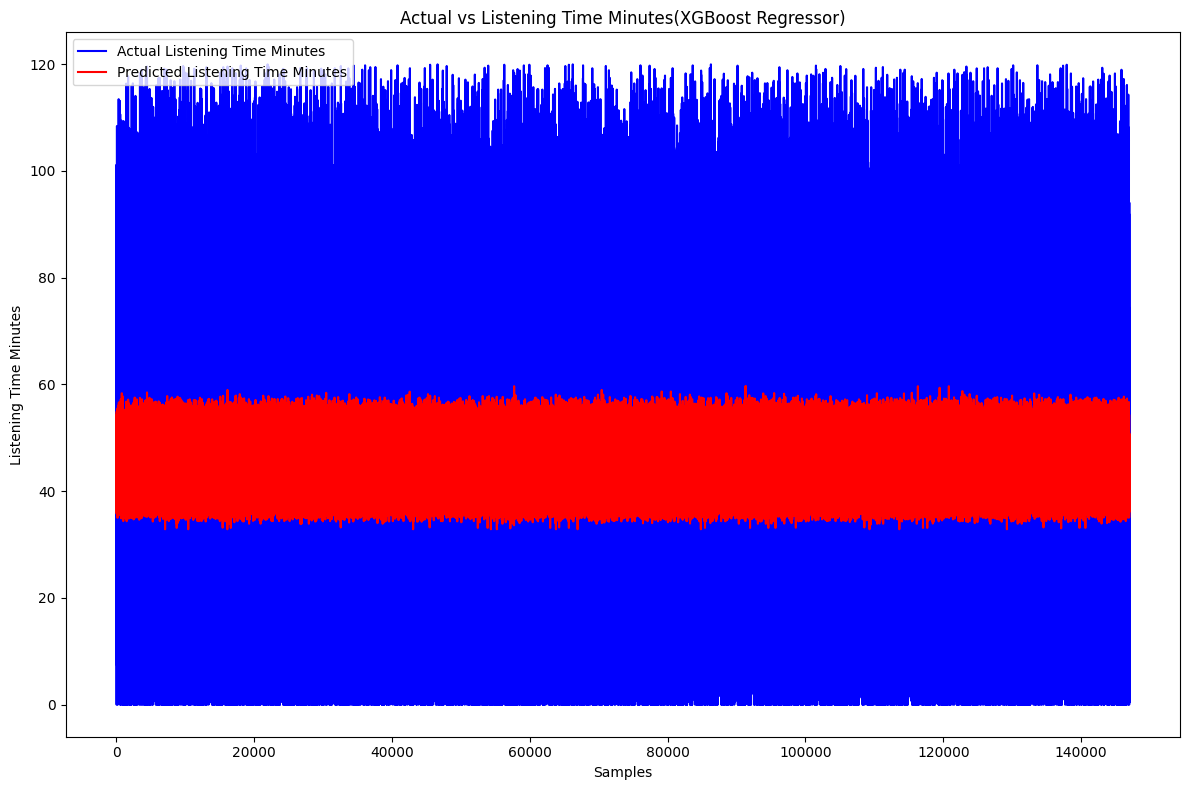

In [28]:
# Plot actual vs predicted
plt.figure(figsize=(12,8))
plt.plot(y_test.values, label='Actual Listening Time Minutes', color='blue')
plt.plot(y_pred, label='Predicted Listening Time Minutes', color='red')
plt.title('Actual vs Listening Time Minutes(XGBoost Regressor)')
plt.xlabel('Samples')
plt.ylabel('Listening Time Minutes')
plt.legend()
plt.tight_layout()
plt.show()

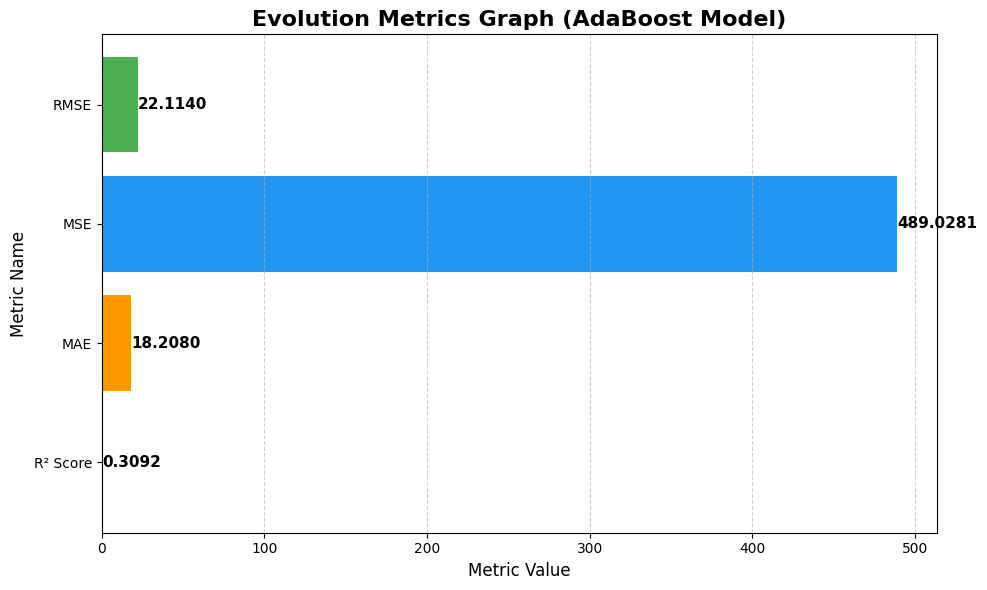

In [29]:
# Define metrics
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
}

# Create a figure
plt.figure(figsize=(10,6))

# Horizontal bar chart for better readability
plt.barh(list(metrics.keys()), list(metrics.values()), color=['#4CAF50', '#FF9800', '#2196F3'])

# Title and labels
plt.title('Evolution Metrics Graph (AdaBoost Model)', fontsize=16, fontweight='bold')
plt.xlabel('Metric Value', fontsize=12)
plt.ylabel('Metric Name', fontsize=12)

# Add metric values beside bars
for i, (key, value) in enumerate(metrics.items()):
    plt.text(value + 0.01, i, f"{value:.4f}", va='center', fontsize=11, fontweight='bold')

# Grid and style
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


📈 Optimization History


<Figure size 2000x1200 with 0 Axes>

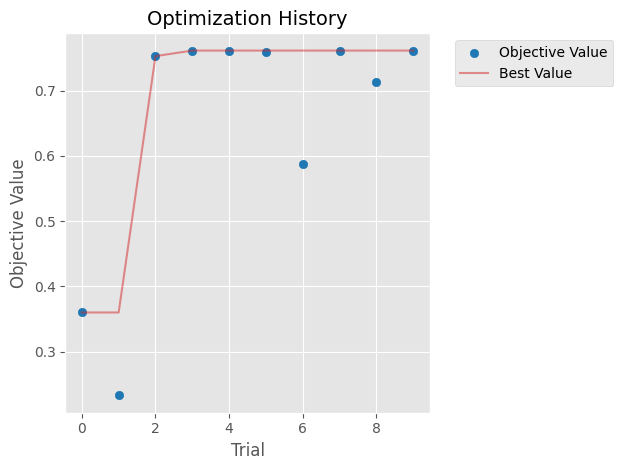


📈 Parallel Coordinate


<Figure size 2000x1200 with 0 Axes>

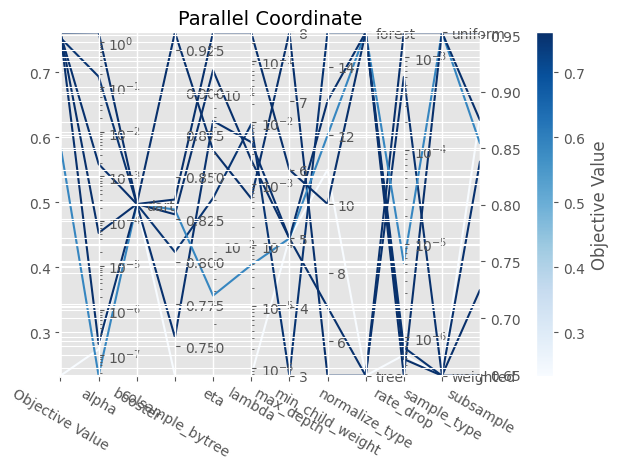


📈 Parameter Importances


<Figure size 2000x1200 with 0 Axes>

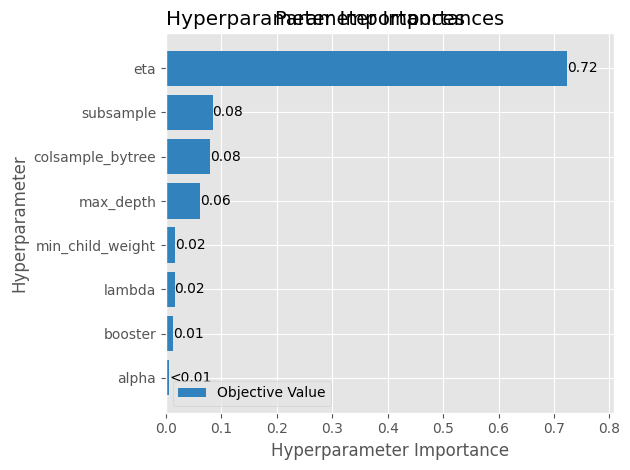


📈 Empirical Distribution Function (EDF)


<Figure size 2000x1200 with 0 Axes>

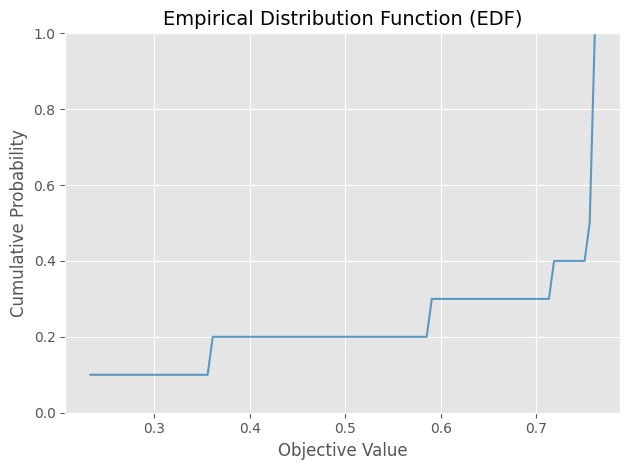


📈 Parameter Slice Plot


<Figure size 2000x1200 with 0 Axes>

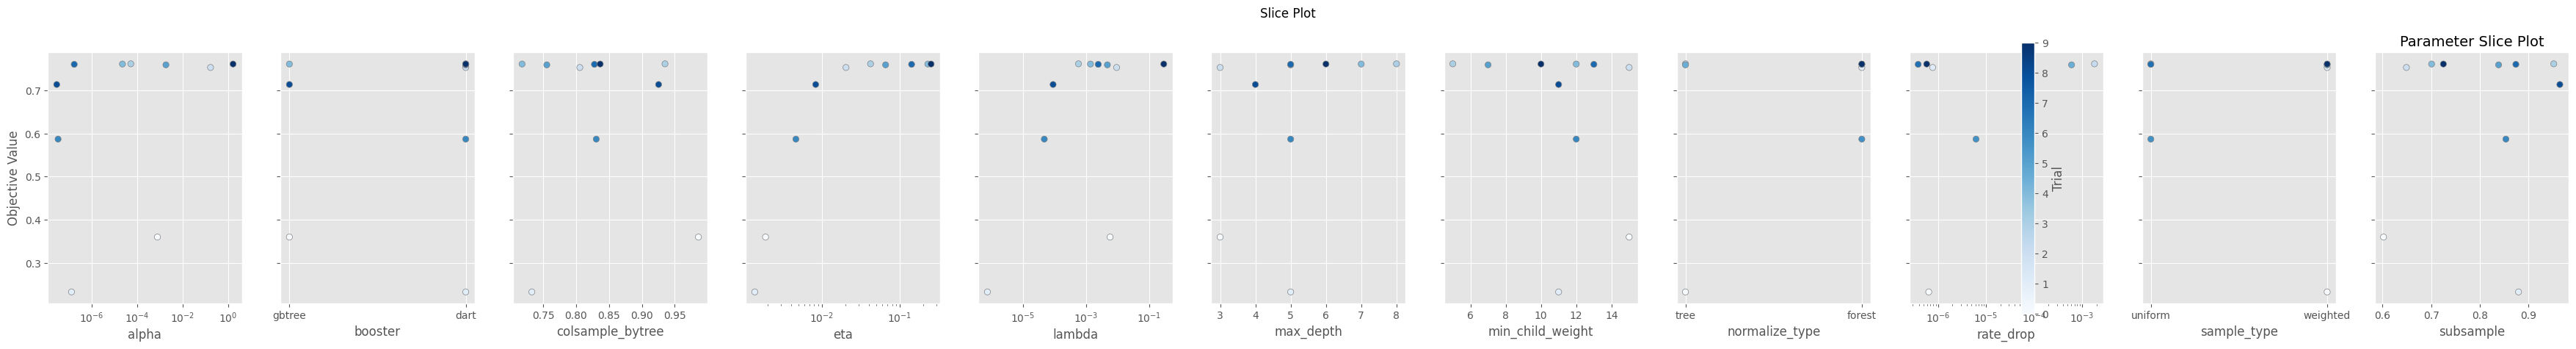

[W 2026-01-01 16:53:56,459] You need to set up the pruning feature to utilize `plot_intermediate_values()`



📈 Intermediate Values (Learning Curve)


<Figure size 2000x1200 with 0 Axes>

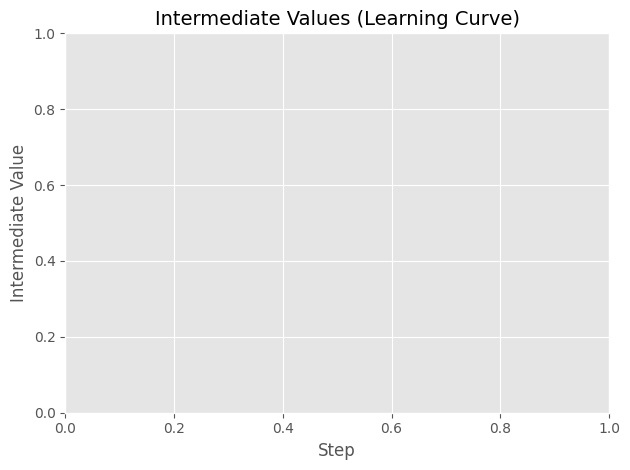

In [30]:
# OPTUNA VISUALIZATIONS (Matplotlib)

from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
    plot_edf,
    plot_slice,
    plot_intermediate_values
)
import matplotlib.pyplot as plt

# List of all plots with descriptive names and plotting functions
plots = [
    ("Optimization History", plot_optimization_history),
    ("Parallel Coordinate", plot_parallel_coordinate),
    ("Parameter Importances", plot_param_importances),
    ("Empirical Distribution Function (EDF)", plot_edf),
    ("Parameter Slice Plot", plot_slice),
    ("Intermediate Values (Learning Curve)", plot_intermediate_values)
]

# Display all plots properly resized
for name, plot_func in plots:
    print(f"\n📈 {name}")
    
    # Create a fresh figure with desired size
    plt.figure(figsize=(20,12))
    
    # Call the plotting function directly on this figure
    ax = plot_func(study)
    
    # Add title (use suptitle if it's a figure)
    if hasattr(ax, "set_title"):
        ax.set_title(name, fontsize=14)
    else:
        plt.title(name, fontsize=14)
    
    plt.tight_layout()
    plt.show()

In [33]:
import joblib

joblib.dump(xgboost_model, "podcast_listening_model.pkl")
xgboost_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

joblib.dump({
    "model": xgboost_model,
    "scaler": scaler,
    "label_encoders": encoders
}, "podcast_listening_full_pipeline.pkl")

print("Full pipeline saved successfully")

Full pipeline saved successfully
